In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
heart_data = pd.read_csv('heart.csv')
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
heart_data.shape

(918, 12)

In [ ]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
import pickle

# Save the best performing model (tuned Random Forest model)
filename = 'best_heart_disease_model.pkl'
pickle.dump(best_rf_model, open(filename, 'wb'))

print(f"Best model saved as {filename}")

Best model saved as best_heart_disease_model.pkl


# EDA


In [ ]:
print("Descriptive statistics for numerical columns:")
display(heart_data.describe())

print("\nValue counts for categorical columns:")
categorical_cols = heart_data.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    display(heart_data[col].value_counts())

Descriptive statistics for numerical columns:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000



Value counts for categorical columns:

Value counts for Sex:


,count
Sex,
M,725
F,193



Value counts for ChestPainType:


...

,count
RestingECG,
Normal,552
LVH,188
ST,178



Value counts for ExerciseAngina:


,count
ExerciseAngina,
N,547
Y,371



Value counts for ST_Slope:


,count
ST_Slope,
Flat,460
Up,395
Down,63


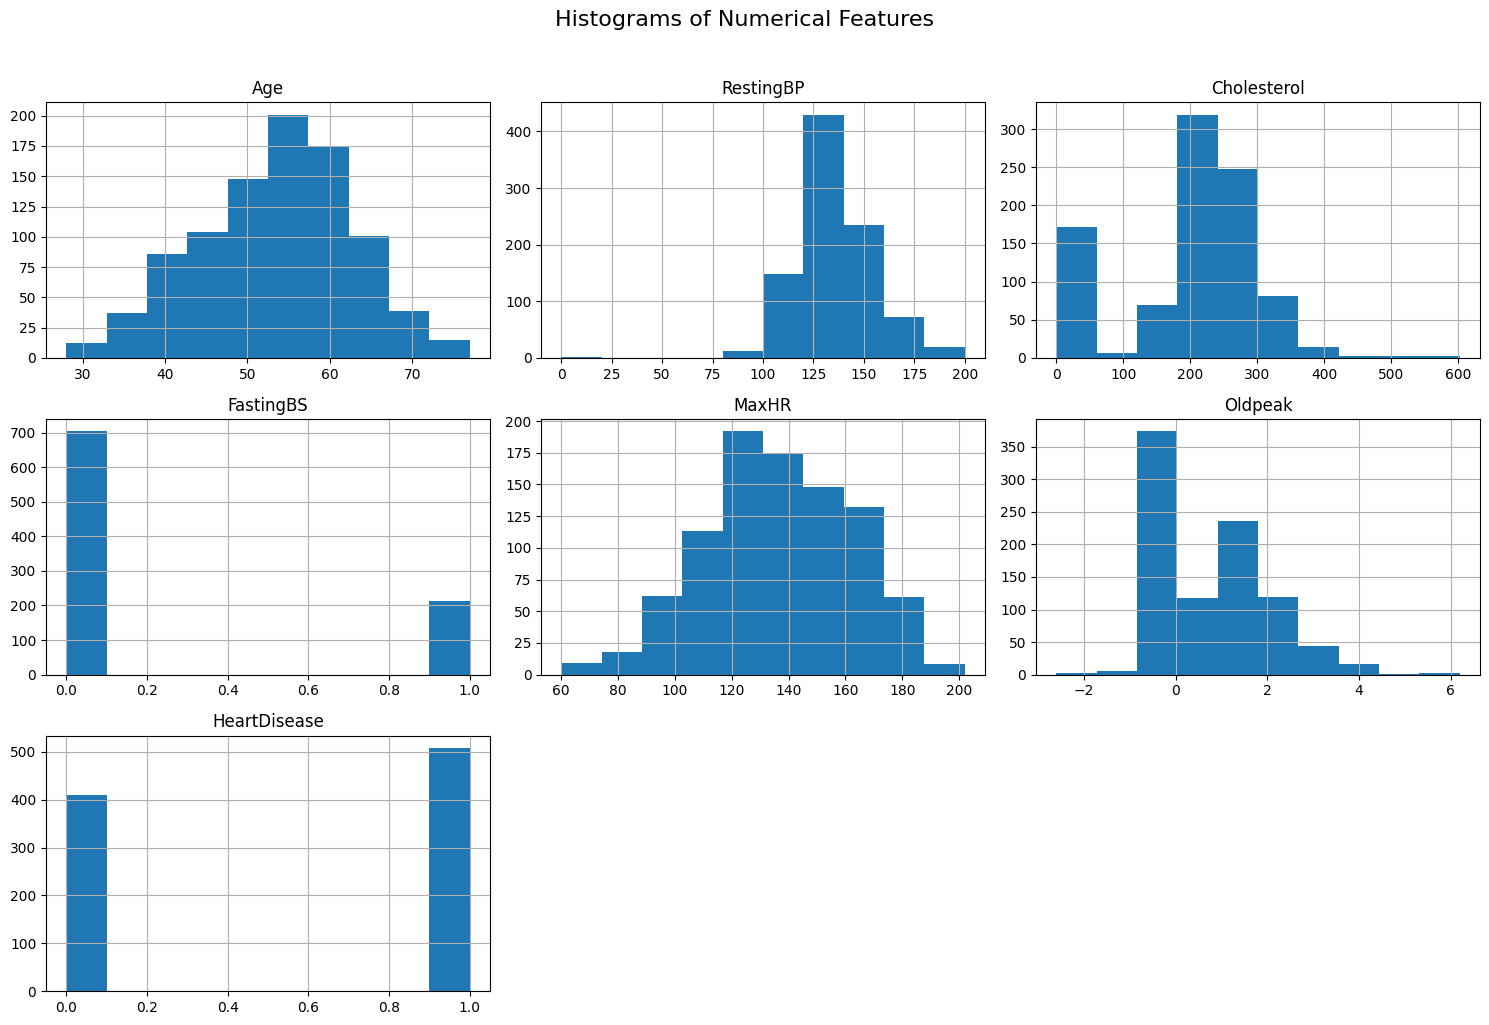

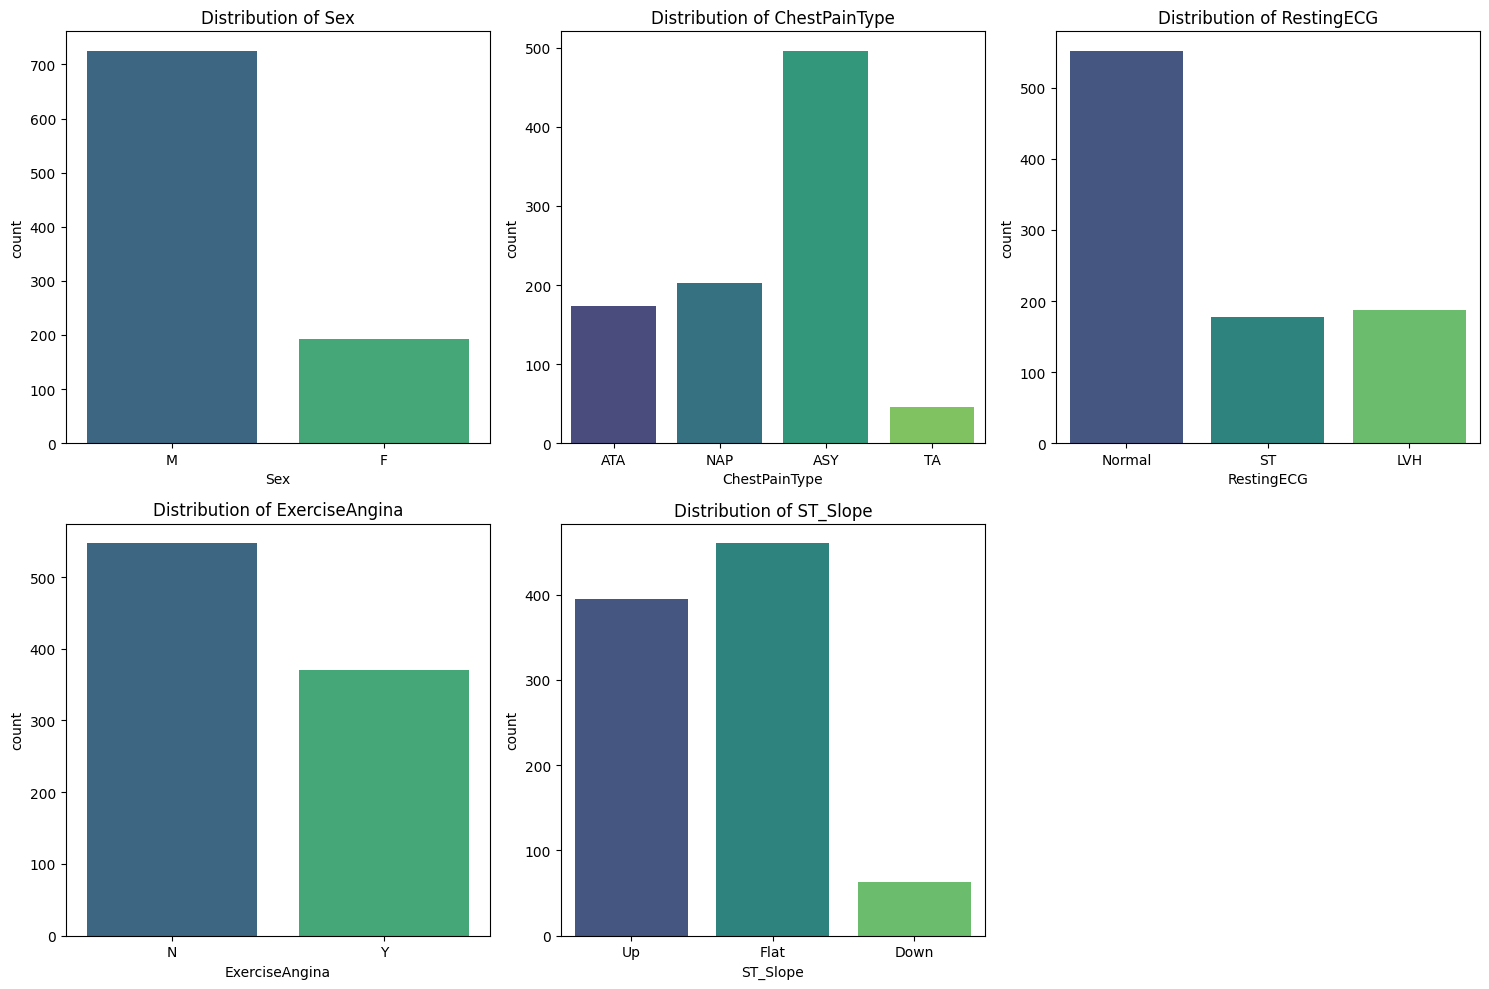

In [ ]:
numerical_cols = heart_data.select_dtypes(include=np.number).columns
heart_data[numerical_cols].hist(figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

categorical_cols = heart_data.select_dtypes(include='object').columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=heart_data, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

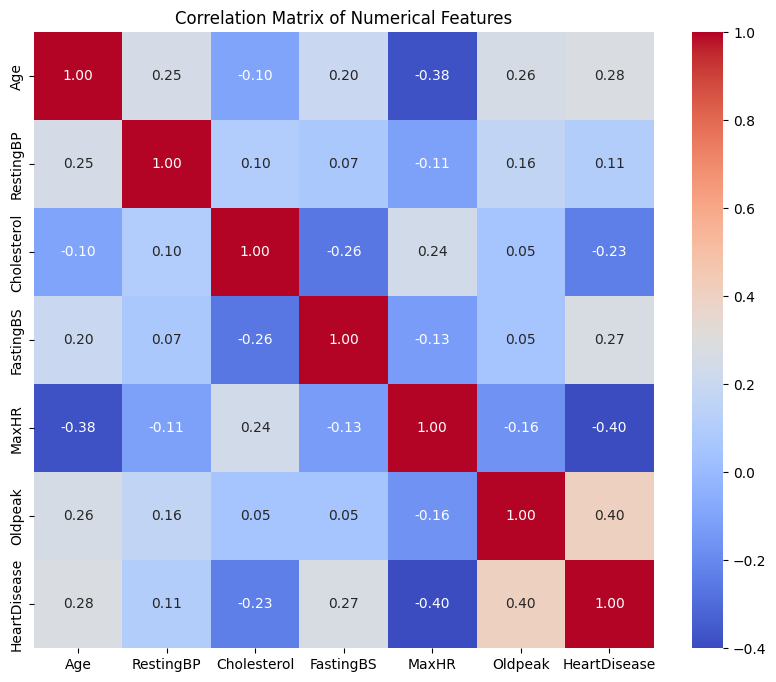

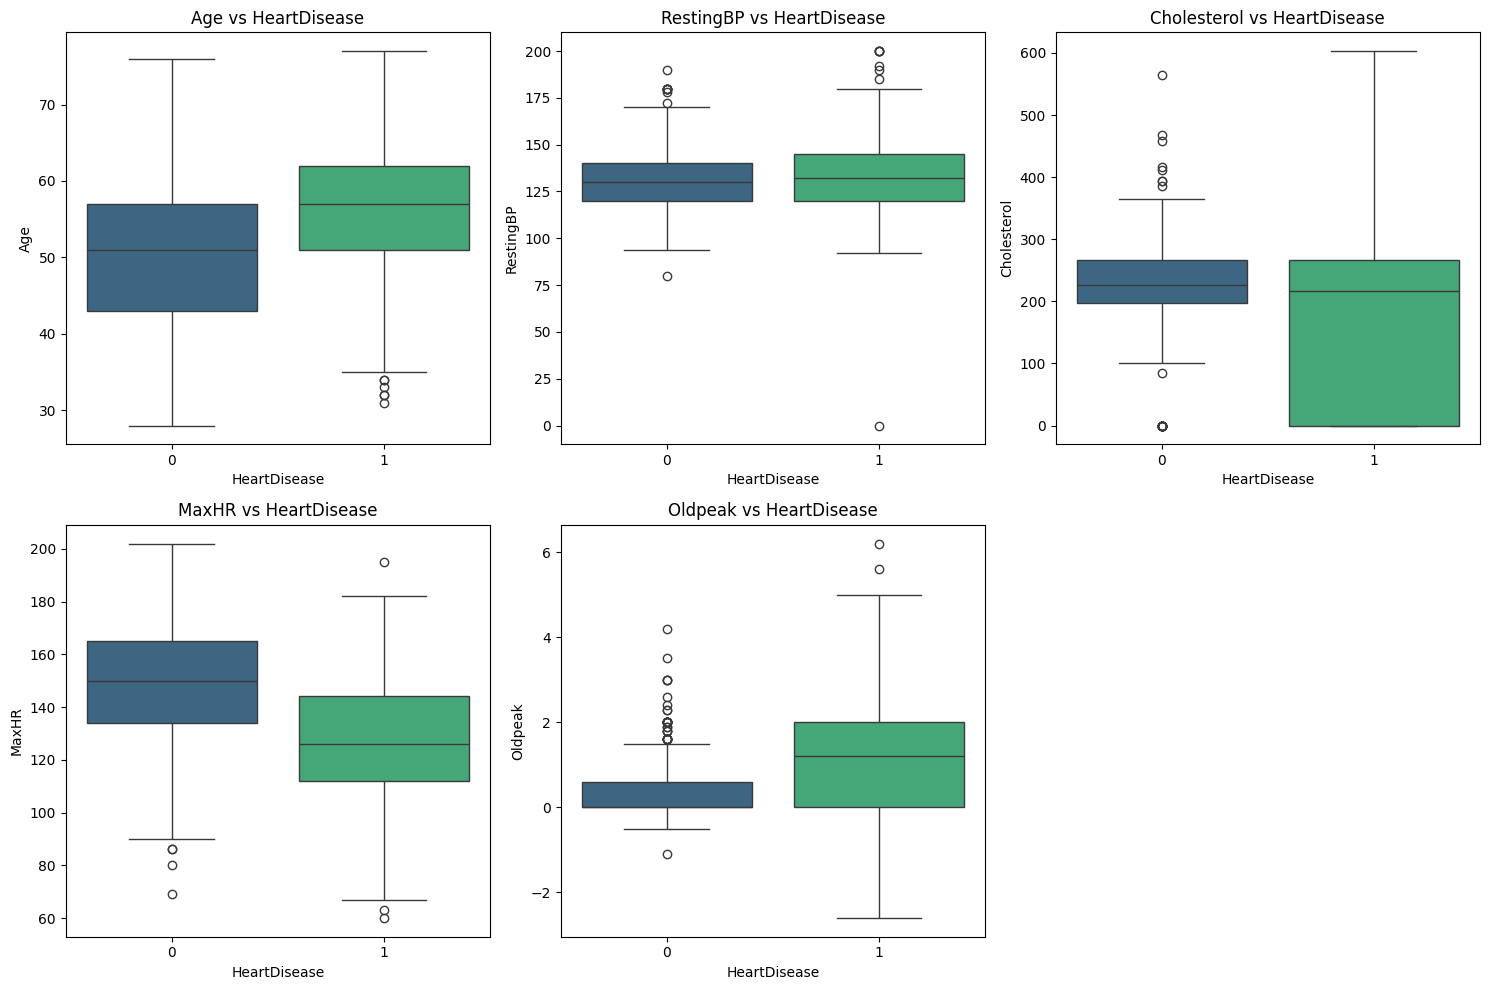

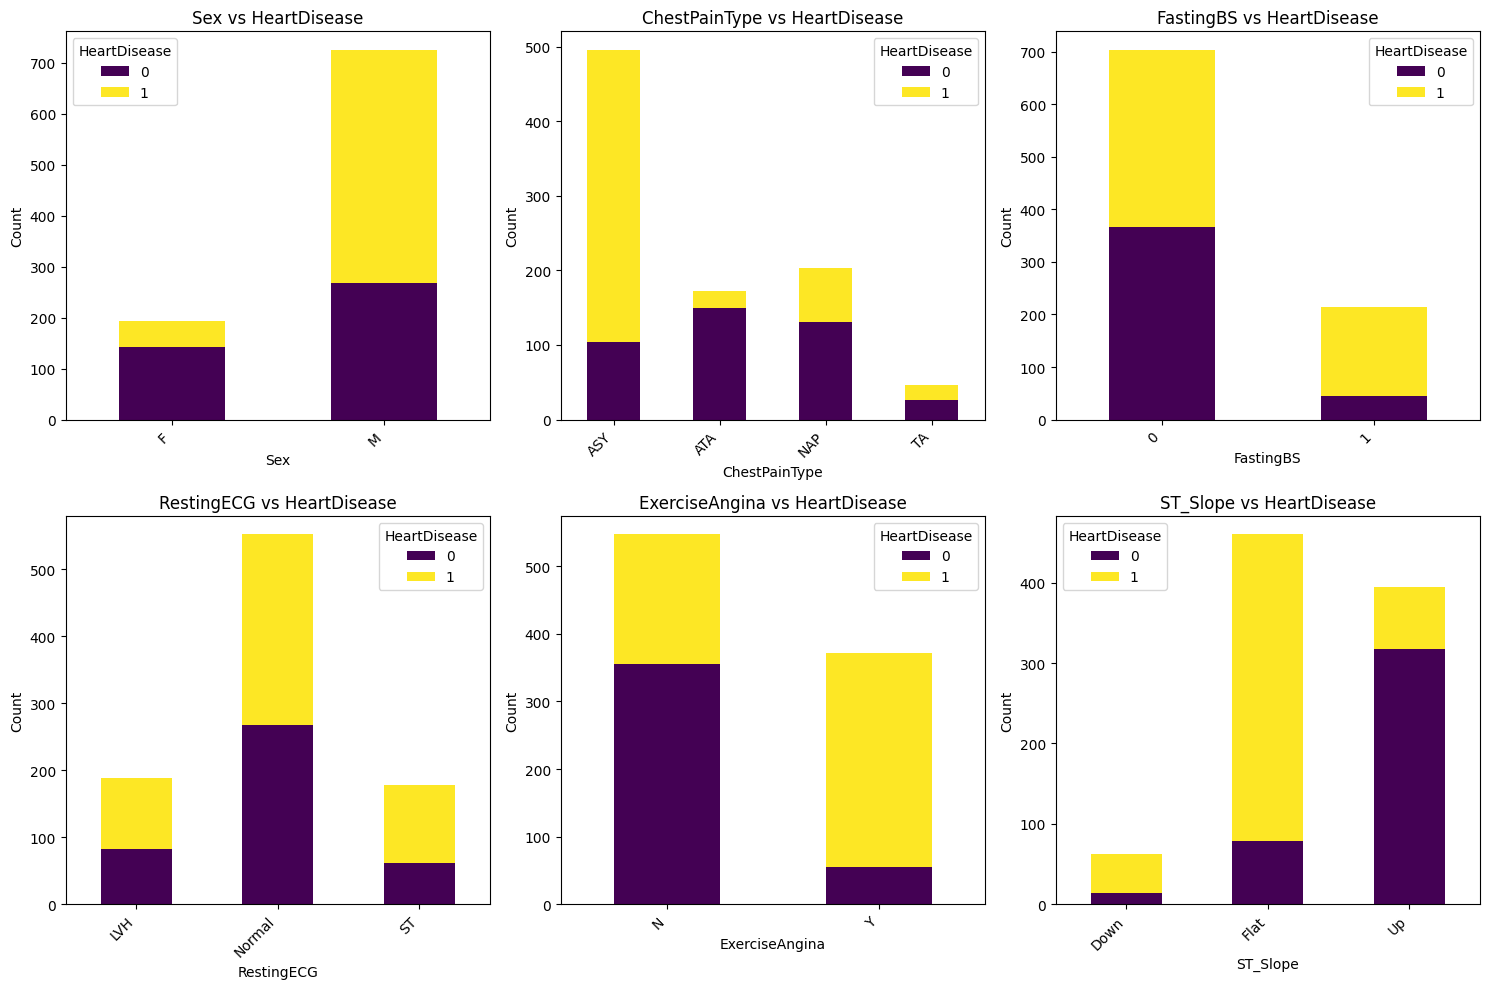

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(heart_data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

numerical_features_for_box = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features_for_box):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=heart_data, x='HeartDisease', y=col, palette='viridis')
    plt.title(f'{col} vs HeartDisease')
plt.tight_layout()
plt.show()

categorical_features_for_stacked = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_features_for_stacked):
    plt.subplot(2, 3, i + 1)
    ct = pd.crosstab(heart_data[col], heart_data['HeartDisease'])
    ct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='viridis')
    plt.title(f'{col} vs HeartDisease')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Data preprocessing

In [ ]:
categorical_cols = heart_data.select_dtypes(include='object').columns
heart_data_encoded = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True)
display(heart_data_encoded.head())

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


# Model selection and training


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X = heart_data_encoded.drop('HeartDisease', axis=1)
y = heart_data_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()

lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier()

# Model evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

results = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC AUC': roc_auc
    }

    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}\n")


--- Logistic Regression ---
Accuracy: 0.8478
Precision: 0.8911
Recall: 0.8411
F1-score: 0.8654
ROC AUC: 0.9188

--- Decision Tree ---
Accuracy: 0.8533
Precision: 0.8636
Recall: 0.8879
F1-score: 0.8756
ROC AUC: 0.8465

--- Random Forest ---
Accuracy: 0.8641
Precision: 0.8868
Recall: 0.8785
F1-score: 0.8826
ROC AUC: 0.9319



# Model comparison and selection


In [ ]:
print("Model Performance Comparison:")
for model_name, metrics in results.items():
    print(f"\n--- {model_name} ---")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

best_model_name = None
best_roc_auc = -1

for model_name, metrics in results.items():
    if metrics['ROC AUC'] > best_roc_auc:
        best_roc_auc = metrics['ROC AUC']
        best_model_name = model_name

print(f"\nBased on ROC AUC, the best performing model is: {best_model_name}")

Model Performance Comparison:

--- Logistic Regression ---
Accuracy: 0.8478
Precision: 0.8911
Recall: 0.8411
F1-score: 0.8654
ROC AUC: 0.9188

--- Decision Tree ---
Accuracy: 0.8533
Precision: 0.8636
Recall: 0.8879
F1-score: 0.8756
ROC AUC: 0.8465

--- Random Forest ---
Accuracy: 0.8641
Precision: 0.8868
Recall: 0.8785
F1-score: 0.8826
ROC AUC: 0.9319

Based on ROC AUC, the best performing model is: Random Forest


# Hyperparameter tuning


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)

Best hyperparameters found by GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)
y_pred_proba_tuned = best_rf_model.predict_proba(X_test)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print("\n--- Tuned Random Forest Model ---")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-score: {f1_tuned:.4f}")
print(f"ROC AUC: {roc_auc_tuned:.4f}")


--- Tuned Random Forest Model ---
Accuracy: 0.8696
Precision: 0.8807
Recall: 0.8972
F1-score: 0.8889
ROC AUC: 0.9307


In [ ]:
print("Random Forest Model Performance Comparison:")
print("-" * 40)
print(f"{'Metric':<15} | {'Original RF':<15} | {'Tuned RF':<15}")
print("-" * 40)
print(f"{'Accuracy':<15} | {results['Random Forest']['Accuracy']:.4f}{'':<9} | {accuracy_tuned:.4f}{'':<9}")
print(f"{'Precision':<15} | {results['Random Forest']['Precision']:.4f}{'':<9} | {precision_tuned:.4f}{'':<9}")
print(f"{'Recall':<15} | {results['Random Forest']['Recall']:.4f}{'':<9} | {recall_tuned:.4f}{'':<9}")
print(f"{'F1-score':<15} | {results['Random Forest']['F1-score']:.4f}{'':<9} | {f1_tuned:.4f}{'':<9}")
print(f"{'ROC AUC':<15} | {results['Random Forest']['ROC AUC']:.4f}{'':<9} | {roc_auc_tuned:.4f}{'':<9}")
print("-" * 40)

if accuracy_tuned > results['Random Forest']['Accuracy']:
    print("\nHyperparameter tuning improved Accuracy.")
else:
    print("\nHyperparameter tuning did not improve Accuracy.")

if precision_tuned > results['Random Forest']['Precision']:
    print("Hyperparameter tuning improved Precision.")
else:
    print("Hyperparameter tuning did not improve Precision.")

if recall_tuned > results['Random Forest']['Recall']:
    print("Hyperparameter tuning improved Recall.")
else:
    print("Hyperparameter tuning did not improve Recall.")

if f1_tuned > results['Random Forest']['F1-score']:
    print("Hyperparameter tuning improved F1-score.")
else:
    print("Hyperparameter tuning did not improve F1-score.")

if roc_auc_tuned > results['Random Forest']['ROC AUC']:
    print("Hyperparameter tuning improved ROC AUC.")
else:
    print("Hyperparameter tuning did not improve ROC AUC.")

Random Forest Model Performance Comparison:
----------------------------------------
Metric          | Original RF     | Tuned RF       
----------------------------------------
Accuracy        | 0.8641          | 0.8696         
Precision       | 0.8868          | 0.8807         
Recall          | 0.8785          | 0.8972         
F1-score        | 0.8826          | 0.8889         
ROC AUC         | 0.9319          | 0.9307         
----------------------------------------

Hyperparameter tuning improved Accuracy.
Hyperparameter tuning did not improve Precision.
Hyperparameter tuning improved Recall.
Hyperparameter tuning improved F1-score.
Hyperparameter tuning did not improve ROC AUC.
